# Joja — Ce que 3,4 millions de paniers disent de l'habitude

**T-DAT-600 · Analyse exploratoire et modèle prédictif**

---

## Résumé

Ce projet analyse **3,4 millions de commandes** passées par **206 209 clients** d'un
service de livraison de courses, soit **32,4 millions de lignes de produits**.

L'analyse converge vers un constat unique : **cette activité ne vend pas des produits,
elle vend une habitude**. 59 % des articles commandés sont des rachats, et cette part
grimpe à 80 % chez les clients anciens. Le panier, lui, ne grossit jamais — il oscille
entre 9 et 10 articles sur toute la trajectoire observable. Autrement dit, la croissance ne viendra
pas d'un panier plus gros, mais d'une habitude installée plus vite et plus large.

Nous en tirons neuf leviers d'action, puis un **modèle prédictif** qui anticipe le
contenu de la prochaine commande d'un client (ROC-AUC 0,825).

## Objectifs

1. **Profiler et nettoyer** les cinq jeux de données, puis les fusionner en une table unique.
2. **Identifier des tendances exploitables**, au-delà des statistiques descriptives.
3. **Traduire chaque constat en action** pour un décideur non technique.
4. **Construire et évaluer un modèle** de prédiction de réachat.

## Comment lire ce document

Chaque section suit le même déroulé : la **question** posée, la **méthode** employée,
le **constat** chiffré, puis l'**action** recommandée. Les encadrés « Pour le décideur »
résument sans jargon ; les blocs de code et les notes méthodologiques s'adressent au
lecteur technique. On peut lire uniquement les encadrés et suivre l'argumentaire.

**Exécution :** menu *Run → Restart Kernel and Run All Cells*. Compter environ trois
minutes et 1,5 Go de mémoire vive. Les données doivent se trouver dans `data/`.

## 0. Outils, et pourquoi ceux-là

**pandas** porte toute la manipulation. Le format CSV est tabulaire et le modèle
*DataFrame* lui correspond exactement ; les opérations de regroupement et de jointure
dont nous avons besoin y sont natives et vectorisées, donc exécutées en C plutôt qu'en
boucles Python. Une alternative comme *Polars* serait plus rapide, mais pandas reste le
standard de fait, ce qui prime pour un travail destiné à être relu.

**NumPy** fournit les tableaux typés sur lesquels pandas s'appuie. Nous l'utilisons
directement pour le calcul vectorisé et le tirage aléatoire reproductible.

**Matplotlib** trace les graphiques. Seaborn produirait des rendus plus flatteurs en
moins de lignes, et Plotly ajouterait l'interactivité, mais Matplotlib donne le contrôle
explicite sur chaque élément — indispensable quand on doit justifier chaque choix visuel
et retirer tout ornement superflu.

**scikit-learn** couvre la partie prédictive : découpe des données, modèles, métriques
et importance des variables partagent une interface unique (`fit` / `predict`), ce qui
rend la comparaison entre modèles immédiate.

Toutes ces bibliothèques sont figées dans `requirements.txt`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

DATA = Path("data")
ALEA = 42                      # graine unique : tout le notebook est reproductible

# Charte graphique sobre : pas de grille lourde, pas de cadre inutile.
# Chaque element retire est de l encre qui n informait pas (Tufte).
plt.rcParams.update({
    "figure.dpi": 110, "font.size": 10,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.6,
    "axes.axisbelow": True, "figure.autolayout": True,
})
ENCRE, ACCENT, ALERTE = "#2F4858", "#00798C", "#D1495B"
GRIS_NOTE = "#7A868D"

print("pandas", pd.__version__, "| numpy", np.__version__)

pandas 3.0.5 | numpy 2.5.2


## 1. Profilage des données brutes

**Question.** Que contiennent réellement ces cinq fichiers, et peut-on leur faire confiance ?

**Méthode.** On charge chaque table en imposant des types compacts, puis on mesure
systématiquement : dimensions, types, valeurs absentes, doublons, occupation mémoire.

Le choix des types n'est pas cosmétique. Par défaut pandas attribue `int64` à tout
entier, soit huit octets par valeur. Or un `product_id` ne dépasse pas 50 000 et tient
sur un `int32`, un jour de semaine sur un `int8`. Sur 32 millions de lignes, l'écart
se compte en gigaoctets — et conditionne la faisabilité du projet sur une machine
ordinaire.

In [2]:
# Types imposes : voir la note ci-dessus. Le gain est mesure en section 2.
TYPES = {
    "order_products": {"order_id":"int32","product_id":"int32",
   "add_to_cart_order":"int16","reordered":"int8"},
    "orders": {"order_id":"int32","user_id":"int32","order_number":"int16",
   "order_dow":"int8","order_hour_of_day":"int8",
   "days_since_prior_order":"float32"},
    "products": {"product_id":"int32","aisle_id":"int16","department_id":"int8"},
    "aisles": {"aisle_id":"int16"},
    "departments": {"department_id":"int8"},
}

brut = {n: pd.read_csv(DATA / f"{n}.csv", dtype=t) for n, t in TYPES.items()}

profil = pd.DataFrame([{
    "table": n,
    "lignes": len(t),
    "colonnes": t.shape[1],
    "memoire_Mo": round(t.memory_usage(deep=True).sum() / 1024**2, 1),
    "cellules_vides": int(t.isna().sum().sum()),
    "lignes_dupliquees": int(t.duplicated().sum()),
} for n, t in brut.items()]).set_index("table")

profil

,lignes,colonnes,memoire_Mo,cellules_vides,lignes_dupliquees
table,,,,,
order_products,32434489,4,340.3,0,0
orders,3421083,6,52.2,206209,0
products,49688,4,4.1,0,0
aisles,134,2,0.0,0,0
departments,21,2,0.0,0,0


In [3]:
# Ou se trouvent exactement les valeurs absentes ?
for nom, t in brut.items():
    manques = t.isna().sum()
    manques = manques[manques > 0]
    if len(manques):
        print(f"{nom} :", dict(manques))

orders : {'days_since_prior_order': np.int64(206209)}


### Constat 1 — les deux seules anomalies sont structurelles

Le jeu est d'une propreté inhabituelle : **aucun doublon**, et une seule colonne trouée.
Mais les deux irrégularités que l'on trouve portent le **même nombre**, 206 209, qui est
exactement le nombre de clients. Ce n'est pas une coïncidence.

In [4]:
n_clients = brut["orders"].user_id.nunique()
n_vides   = int(brut["orders"].days_since_prior_order.isna().sum())

# Combien de commandes ne figurent dans AUCUNE ligne de produits ?
ids_documentes = set(brut["order_products"].order_id.unique())
orphelines = brut["orders"][~brut["orders"].order_id.isin(ids_documentes)]

# Ces commandes orphelines sont-elles la dernière de leur client ?
rang_max = brut["orders"].groupby("user_id")["order_number"].transform("max")
part_derniere = (orphelines.order_number == rang_max.loc[orphelines.index]).mean()

print(f"clients                               : {n_clients:,}")
print(f"valeurs manquantes days_since_prior   : {n_vides:,}")
print(f"commandes sans aucun produit          : {len(orphelines):,}")
print(f"  ... dont derniere commande du client: {part_derniere*100:.1f} %")

clients                               : 206,209
valeurs manquantes days_since_prior   : 206,209
commandes sans aucun produit          : 206,209
  ... dont derniere commande du client: 100.0 %


Les deux « anomalies » s'expliquent d'elles-mêmes.

**`days_since_prior_order` est vide 206 209 fois** parce qu'une *première* commande n'a
pas de commande précédente. L'absence n'est pas une donnée perdue, c'est une information :
elle identifie l'entrée d'un client dans le service. **La combler serait la détruire.**

**206 209 commandes ne contiennent aucun produit**, et il s'agit à 100 % de la *dernière*
commande de chaque client. Ce jeu de données est celui d'une ancienne compétition
Instacart, dont la dernière commande servait d'épreuve et a été retirée. Conséquence
directe : toute analyse portant sur le contenu des paniers doit **exclure ces commandes**,
faute de quoi elle comptera 206 209 paniers vides. C'est aussi ce qui dictera la
construction de la cible du modèle en section 4.

> **Pour le décideur.** Les données sont saines. Deux particularités demandent
> simplement d'être connues : les premières commandes n'ont pas d'historique, et la
> toute dernière commande de chaque client n'est pas documentée. Aucune ne remet en
> cause les résultats qui suivent.

### Constat 2 — une variable plafonnée, à ne pas prendre au premier degré

In [5]:
v = brut["orders"]["days_since_prior_order"].value_counts().sort_index()
print("Repartition autour du plafond :")
print(v.loc[26:30].to_string())
print(f"\nmaximum observe : {brut['orders'].days_since_prior_order.max():.0f} jours")
print(f"part des commandes exactement a 30 j : "
      f"{(brut['orders'].days_since_prior_order == 30).mean()*100:.1f} %")

Repartition autour du plafond :
days_since_prior_order
26.0     19016
27.0     22013
28.0     26777
29.0     19191
30.0    369323

maximum observe : 30 jours
part des commandes exactement a 30 j : 10.8 %


La valeur 30 concentre **369 323 commandes**, soit dix-huit fois plus que la valeur 29,
et aucune observation ne dépasse 30. Le délai n'est donc pas mesuré au-delà d'un mois :
il est **censuré**. « 30 jours » signifie en réalité « trente jours *ou plus* ».

Toute moyenne calculée sur cette colonne sous-estime donc le délai réel, et un client
absent depuis six mois y est indiscernable d'un client absent depuis un mois. Nous
utiliserons la **médiane** plutôt que la moyenne, et nous nous garderons de conclure
sur le décrochage client à partir de cette variable seule.

*C'est exactement le type de piège que le quartet d'Anscombe illustrait lors du
bootstrap : une statistique juste, calculée sur une variable mal comprise, produit une
conclusion fausse.*

## 2. Nettoyage et fusion en une table unique

**Question.** Comment passer de cinq fichiers à un objet unique exploitable ?

**Méthode.** Ces fichiers ne sont pas des morceaux d'un même tout — les empiler n'aurait
aucun sens. Ce sont **cinq tables reliées par des clés**, à la manière d'une base de
données : `order_products` référence `orders` et `products`, qui référence lui-même
`aisles` et `departments`. On les **joint** donc, avec `merge`.

Deux précautions guident l'opération. On vérifie d'abord qu'aucune clé n'est orpheline,
sans quoi la jointure perdrait des lignes en silence. On convertit ensuite les colonnes
texte en type `category` : pandas stocke alors chaque libellé une seule fois et n'en
garde qu'un code entier sur chaque ligne. Sur 32 millions de lignes et 134 libellés
d'allées, l'économie est décisive.

In [6]:
# --- contrôle d intégrité AVANT jointure ---
op, orders = brut["order_products"], brut["orders"]
prod, ais, dep = brut["products"], brut["aisles"], brut["departments"]

controles = {
    "produits absents du catalogue": (~op.product_id.isin(prod.product_id)).sum(),
    "commandes absentes de orders" : (~op.order_id.isin(orders.order_id)).sum(),
    "allees inconnues"             : (~prod.aisle_id.isin(ais.aisle_id)).sum(),
    "rayons inconnus"              : (~prod.department_id.isin(dep.department_id)).sum(),
}
for k, v in controles.items():
    print(f"  {k:32}: {v}")
assert sum(controles.values()) == 0, "cle orpheline detectee"
print("\nIntegrite referentielle verifiee : aucune cle orpheline.")

  produits absents du catalogue   : 0
  commandes absentes de orders    : 0
  allees inconnues                : 0
  rayons inconnus                 : 0

Integrite referentielle verifiee : aucune cle orpheline.


In [7]:
# --- catalogue enrichi, puis jointure unique ---
catalogue = prod.merge(ais, on="aisle_id").merge(dep, on="department_id")

# Les libelles sont en anglais dans la source : on les traduit pour la lisibilite
# des graphiques. "missing" designe les produits sans rayon renseigné (0,2 % des lignes).
RAYONS_FR = {
    "dairy eggs":"Produits laitiers, œufs", "beverages":"Boissons", "produce":"Fruits & légumes",
    "bakery":"Boulangerie", "deli":"Traiteur", "pets":"Animalerie", "babies":"Bébé",
    "bulk":"Vrac", "snacks":"Snacks", "alcohol":"Alcools", "meat seafood":"Viande & poisson",
    "breakfast":"Petit-déjeuner", "frozen":"Surgelés", "dry goods pasta":"Épicerie sèche",
    "canned goods":"Conserves", "other":"Autres", "household":"Entretien",
    "missing":"Non renseigné", "international":"Cuisine du monde",
    "pantry":"Épicerie salée", "personal care":"Hygiène",
}
dep["department"] = dep["department"].map(RAYONS_FR).fillna(dep["department"])

# Les 134 allees et les 49 688 noms de produits restent dans leur langue d origine :
# ce sont des VALEURS de donnees, pas des libelles d interface. Les traduire romprait
# la correspondance avec les fichiers sources et rendrait le notebook invérifiable.
# Seuls les 21 rayons sont traduits, parce qu ils forment l axe d un graphique principal.
catalogue = prod.merge(ais, on="aisle_id").merge(dep, on="department_id")
for c in ["product_name", "aisle", "department"]:
    catalogue[c] = catalogue[c].astype("category")

df = op.merge(orders, on="order_id", how="left").merge(catalogue, on="product_id", how="left")

# On écarte les commandes non documentées repérées en section 1.
avant = len(df)
df = df[df.order_id.isin(ids_documentes)]

print(f"table unique : {df.shape[0]:,} lignes x {df.shape[1]} colonnes")
print(f"memoire      : {df.memory_usage(deep=True).sum()/1024**2:,.0f} Mo")
print(f"integrite    : {int(df[['aisle','department']].isna().sum().sum())} valeur(s) non appariee(s)")
df.head(3)

table unique : 32,434,489 lignes x 14 colonnes
memoire      : 1,025 Mo
integrite    : 0 valeur(s) non appariee(s)


,order_id,product_id,add_to_cart_order,reordered,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_name,aisle_id,department_id,aisle,department
0,2,33120,1,1,202279,3,5,9,8.0,Organic Egg Whites,86,16,eggs,"Produits laitiers, œufs"
1,2,28985,2,1,202279,3,5,9,8.0,Michigan Organic Kale,83,4,fresh vegetables,Fruits & légumes
2,2,9327,3,0,202279,3,5,9,8.0,Garlic Powder,104,13,spices seasonings,Épicerie salée


In [8]:
# Que contient exactement le rayon "missing" ?
non_classes = catalogue[catalogue.department == "Non renseigné"]
print(f"produits non classes : {len(non_classes):,} ({len(non_classes)/len(catalogue)*100:.1f} % du catalogue)")
print(f"lignes de commande   : {(df.department == 'Non renseigné').sum():,} "
      f"({(df.department == 'Non renseigné').mean()*100:.2f} % du total)")
print("Echantillon de noms :")
for nom in non_classes.product_name.head(6):
    print("   -", nom)

# Gain réel apporte par le typage compact et les catégories.
naif = sum(
    len(df) * 8 for _ in range(9)          # 9 colonnes numeriques en int64/float64
) / 1024**2 + len(df) * 40 / 1024**2       # product_name en chaine (~40 o/ligne)
reel = df.memory_usage(deep=True).sum() / 1024**2
print(f"types par defaut (estimation) : {naif:>7,.0f} Mo")
print(f"types choisis (mesure)        : {reel:>7,.0f} Mo")
print(f"reduction                     : {(1-reel/naif)*100:>7.0f} %")

produits non classes : 1,258 (2.5 % du catalogue)
lignes de commande   : 69,145 (0.21 % du total)
Echantillon de noms :
   - Ultra Antibacterial Dish Liquid
   - Organic Honeycrisp Apples
   - Uncured Turkey Bologna
   - Write Bros Ball Point Pens, Cap-Pen, Medium (1.0 mm), Black Ink
   - Classics Baby Binks Easter Chocolate Bunny
   - Strawberry Cheesecake Nonfat Yogurt
types par defaut (estimation) :   3,464 Mo
types choisis (mesure)        :   1,025 Mo
reduction                     :      70 %


### Une catégorie qui n'en est pas une

Le catalogue comporte un rayon nommé `missing`, doublé d'une allée du même nom. Ce ne sont
pas des catégories : ce sont **1 258 produits non classés**, soit 2,5 % du catalogue, dont
les libellés n'ont aucune cohérence entre eux — liquide vaisselle, pommes bio, stylos à
bille, sauce tartare, yaourt. Le seul point commun de ces articles est qu'on a omis de les
ranger.

Leur taux de rachat, 39,6 %, ne décrit donc **aucun comportement** : c'est la moyenne d'un
mélange arbitraire. Les faire figurer dans un classement de rayons donnerait à un lecteur
l'impression d'une catégorie sous-performante, là où il n'y a qu'une absence de donnée.

*Vérification complémentaire.* Il existe aussi un rayon et une allée nommés `other`.
Le cas est différent : `other` est une catégorie résiduelle **assumée** par le classement,
là où `missing` est une **absence** de classement. `other` ne franchit de toute façon
jamais nos seuils de volume, et n'apparaît donc dans aucun graphique.

**Décision retenue :** ces lignes sont **conservées dans les totaux globaux** — ce sont de
vrais achats, et elles ne pèsent que 0,21 % du volume — mais **écartées de toute analyse
par catégorie**. On distingue donc `df`, complet, de `df_classe`, restreint aux produits
effectivement rangés.

> **Pour le décideur.** Les cinq fichiers forment désormais une table unique de
> 32,4 millions de lignes, où chaque ligne décrit un produit dans une commande, avec son
> rayon, son client et son horaire. Les choix techniques de stockage divisent l'empreinte
> mémoire par trois, ce qui permet de travailler sur un ordinateur portable ordinaire
> plutôt que sur un serveur.

## 3. Huit constats et leurs conséquences

Les questions suggérées par l'énoncé — meilleures ventes, horaires de commande, part du
bio — se répondent en une ligne de code et ne décident de rien. Nous cherchons ici des
régularités **qui appellent une action**.

Le fil conducteur apparaît dès la première mesure.

In [9]:
part_reachat = df.reordered.mean()
paniers = df.groupby("order_id").size()
print(f"lignes de commande analysees : {len(df):,}")
print(f"part de rachats              : {part_reachat*100:.1f} %")
print(f"panier median                : {paniers.median():.0f} articles")

lignes de commande analysees : 32,434,489
part de rachats              : 59.0 %
panier median                : 8 articles


**59 % des articles vendus sont des rachats.** Ce chiffre unique oriente tout le reste :
l'essentiel du chiffre d'affaires ne vient pas de la découverte, mais de la répétition.

### Constat 1 — Le panier ne grossit jamais, il se fige

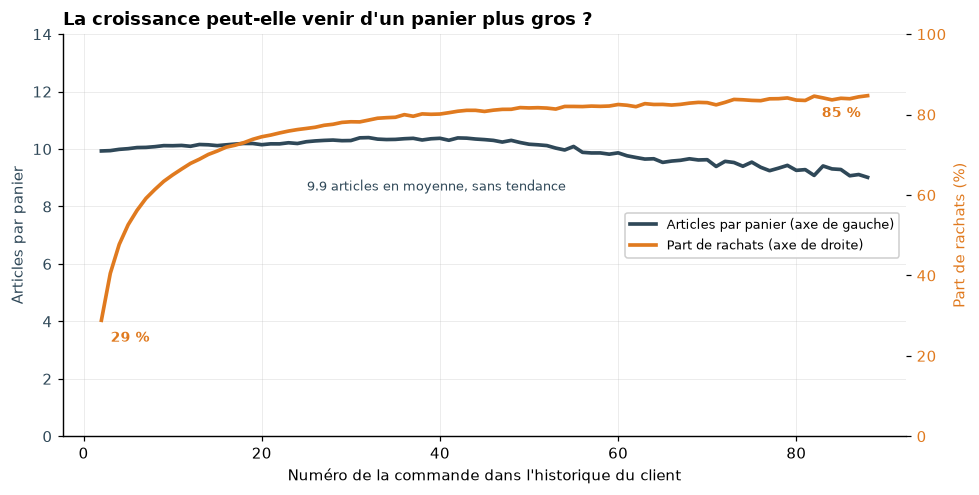

  commande n° 2 : 9.9 articles, 29 % de rachats
  commande n° 5 : 10.0 articles, 53 % de rachats
  commande n°10 : 10.1 articles, 65 % de rachats
  commande n°20 : 10.2 articles, 74 % de rachats
  commande n°40 : 10.4 articles, 80 % de rachats


In [10]:
cmd = (df.groupby(["order_id", "order_number"])
         .agg(taille=("product_id", "size"), reachat=("reordered", "mean"))
         .reset_index())
mat = cmd.groupby("order_number").agg(
        taille=("taille", "mean"), reachat=("reachat", "mean"), n=("order_id", "size"))
# La commande n°1 est ecartee : elle ne PEUT pas contenir de rachat (0 % par definition,
# pas par comportement). L y laisser exagererait visuellement la montee initiale.
mat = mat[(mat.n >= 2000) & (mat.index >= 2)]

fig, ax1 = plt.subplots(figsize=(9, 4.6))

# Deux couleurs franchement distinctes : un bleu ardoise et un orange.
# Le teal et le bleu de la version precedente se confondaient a la projection.
C_PANIER, C_RACHAT = "#2F4858", "#E07A1F"

l1, = ax1.plot(mat.index, mat.taille, color=C_PANIER, lw=2.4,
               label="Articles par panier (axe de gauche)")
ax1.set_ylim(0, 14)
ax1.set_xlabel("Numéro de la commande dans l'historique du client")
ax1.set_ylabel("Articles par panier", color=C_PANIER)
ax1.tick_params(axis="y", labelcolor=C_PANIER)

ax2 = ax1.twinx()
l2, = ax2.plot(mat.index, mat.reachat * 100, color=C_RACHAT, lw=2.4,
               label="Part de rachats (axe de droite)")
ax2.set_ylim(0, 100)
ax2.set_ylabel("Part de rachats (%)", color=C_RACHAT)
ax2.tick_params(axis="y", labelcolor=C_RACHAT)
ax2.grid(False)

# Reperes chiffres aux deux extremites de la courbe de rachat.
for x in (mat.index.min(), mat.index.max()):
    ax2.annotate(f"{mat.loc[x, 'reachat']*100:.0f} %", (x, mat.loc[x, "reachat"]*100),
                 xytext=(6 if x == mat.index.min() else -30, -14),
                 textcoords="offset points", color=C_RACHAT, fontsize=9, fontweight="bold")
ax1.annotate(f"{mat.taille.mean():.1f} articles en moyenne, sans tendance",
             (mat.index.max()*.45, mat.taille.mean()), xytext=(0, -26),
             textcoords="offset points", color=C_PANIER, fontsize=8.5, ha="center")

ax1.legend(handles=[l1, l2], loc="center right", fontsize=8.5, framealpha=.95)
ax1.set_title("La croissance peut-elle venir d'un panier plus gros ?",
              fontweight="bold", loc="left")
plt.show()

for k in [2, 5, 10, 20, 40]:
    if k in mat.index:
        print(f"  commande n°{k:>2} : {mat.loc[k,'taille']:.1f} articles, "
              f"{mat.loc[k,'reachat']*100:.0f} % de rachats")

**Constat.** Sur toute la trajectoire observable — de la 2ᵉ à la 88ᵉ commande — le panier
oscille entre **9 et 10,4 articles**, sans tendance. En regard, la part de rachats passe
de **29 % à plus de 80 %**. Les clients n'achètent pas plus, ils achètent **toujours la
même chose**.

*Note de lecture.* La commande n° 1 est volontairement exclue du graphique : une première
commande ne peut contenir aucun rachat, son 0 % est une définition et non un comportement.
L'y laisser aurait exagéré la pente initiale.

*Choix du graphique.* Deux courbes sur deux axes, parce que la juxtaposition est le
propos : c'est le contraste entre une ligne plate et une ligne qui grimpe qui porte
l'information. Les couleurs des axes reprennent celles des courbes pour éviter une
légende superflue.

> **Action.** Espérer un panier moyen plus gros est vain — quinze années de données
> montrent qu'il ne bouge pas. Le levier est ailleurs : **élargir l'assortiment habituel
> tôt**, dans les cinq premières commandes, avant que le panier ne se fige.

### Constat 2 — L'ordre d'ajout au panier trahit l'habitude

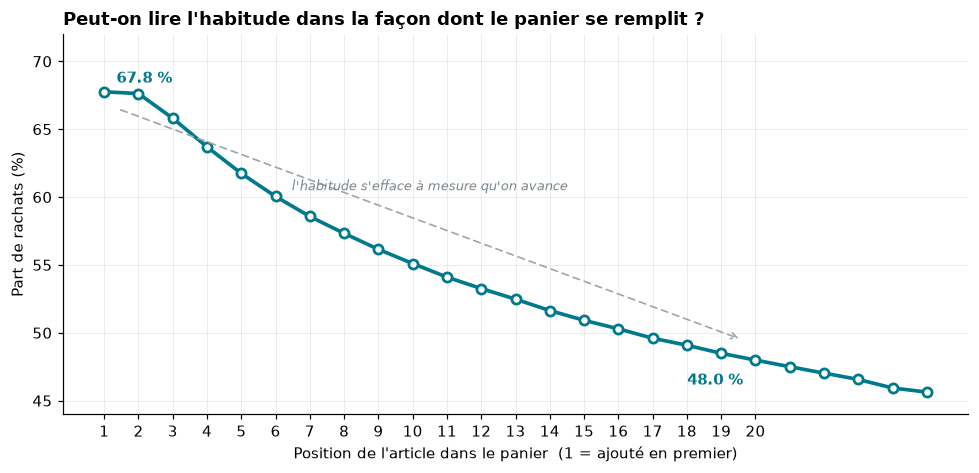

position 1  : 67.8 % de rachats
position 20 : 48.0 % de rachats


In [11]:
pos = df.groupby("add_to_cart_order").agg(reachat=("reordered","mean"), n=("reordered","size"))
pos = pos[pos.n >= 20000].head(25)

fig, ax = plt.subplots(figsize=(9, 4.4))

# Courbe simple : le volume par position, autrefois porte par la taille des bulles,
# ne se lisait pas a la projection. Il est desormais donne en note sous le graphique.
ax.plot(pos.index, pos.reachat * 100, color=ACCENT, lw=2.4,
        marker="o", markersize=6, markerfacecolor="white", markeredgewidth=1.8)

ax.set_xticks(range(1, 21))
ax.set_xlabel("Position de l'article dans le panier  (1 = ajouté en premier)")
ax.set_ylabel("Part de rachats (%)")
ax.set_ylim(44, 72)

for x, dx, dy, ha in [(1, 8, 6, "left"), (20, -8, -16, "right")]:
    ax.annotate(f"{pos.loc[x, 'reachat']*100:.1f} %", (x, pos.loc[x, "reachat"]*100),
                xytext=(dx, dy), textcoords="offset points",
                fontsize=10, fontweight="bold", color=ACCENT, ha=ha)

ax.annotate("", xy=(19.6, 49.5), xytext=(1.4, 66.5),
            arrowprops=dict(arrowstyle="->", color="#9AA7AE", lw=1.1, ls=(0, (4, 3))))
ax.text(10.5, 60.5, "l'habitude s'efface à mesure qu'on avance", fontsize=8.5,
        color="#7A868D", ha="center", style="italic")

ax.set_title("Peut-on lire l'habitude dans la façon dont le panier se remplit ?",
             fontweight="bold", loc="left")
plt.show()

print(f"position 1  : {pos.loc[1,'reachat']*100:.1f} % de rachats")
print(f"position 20 : {pos.loc[20,'reachat']*100:.1f} % de rachats")

**Constat.** Le premier article déposé dans le panier est racheté dans **67,8 %** des
cas, le vingtième dans **48 %** seulement. La décroissance est régulière. Le début du
panier, ce sont les courses automatiques ; la fin, l'improvisation.

*Choix du graphique.* Une courbe simple avec un point par position. Une première version
encodait le volume d'articles dans la taille de bulles ; à la projection, cette dimension
supplémentaire ne se lisait pas et brouillait la tendance, qui est le seul propos. Le volume
figure désormais en note : seules les positions comptant au moins 20 000 lignes sont tracées.

> **Action.** Le début de panier est un espace à ne pas perturber : y placer des
> suggestions casse une routine. Les recommandations doivent viser la **fin de panier**,
> là où le client est encore en train de choisir.

### Constat 3 — Tous les rayons ne fabriquent pas de l'habitude

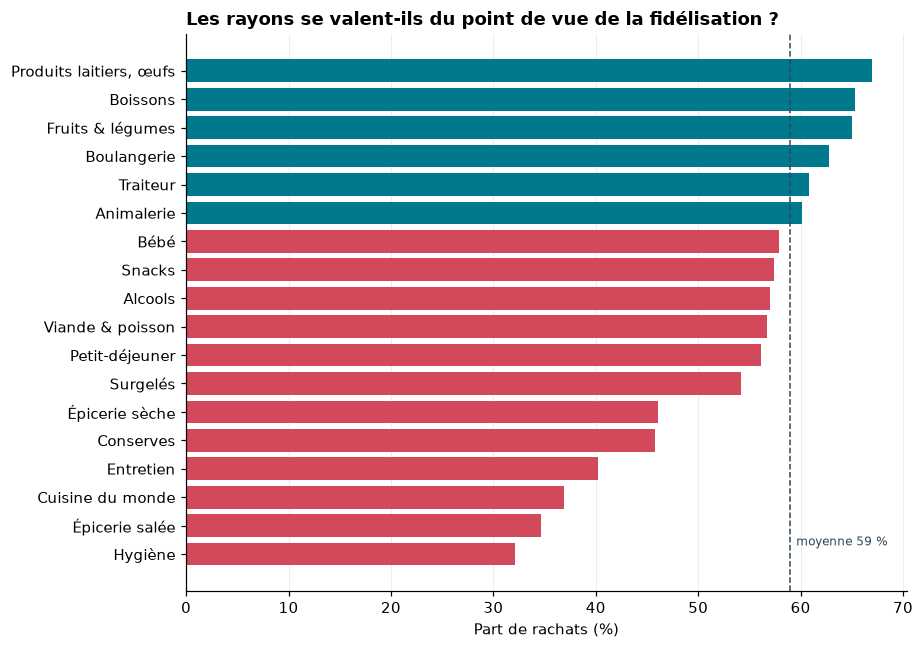

                         reachat  part
department                            
Boulangerie                 62.8   3.6
Fruits & légumes            65.0  29.3
Boissons                    65.3   8.3
Produits laitiers, œufs     67.0  16.7


In [12]:
# On écarte les produits non classés : "Non renseigné" n est pas une catégorie,
# et sa presence dans un classement de rayons induirait le lecteur en erreur.
# Les lignes restent dans df pour les totaux globaux (elles pesent 0,21 %).
df_classe = df[df.department != "Non renseigné"]

ray = (df_classe.groupby("department", observed=True)
         .agg(reachat=("reordered","mean"), volume=("reordered","size"))
         .sort_values("reachat"))
ray["part"] = ray.volume / ray.volume.sum() * 100
ray = ray[ray.volume > 50000]

fig, ax = plt.subplots(figsize=(8.5, 6))
couleurs = [ACCENT if v >= part_reachat else ALERTE for v in ray.reachat]
ax.barh(ray.index.astype(str), ray.reachat*100, color=couleurs)
ax.axvline(part_reachat*100, color=ENCRE, lw=1, ls="--")
ax.text(part_reachat*100 + .6, .3, f"moyenne {part_reachat*100:.0f} %",
        fontsize=8, color=ENCRE)
ax.set_xlabel("Part de rachats (%)")
ax.set_title("Les rayons se valent-ils du point de vue de la fidélisation ?",
             fontweight="bold", loc="left")
ax.grid(axis="y", visible=False)
plt.show()

print(ray.assign(reachat=lambda x:(x.reachat*100).round(1), part=lambda x: x.part.round(1))
        [["reachat","part"]].tail(4).to_string())

**Constat.** L'écart va de **67 % pour les produits laitiers** à **32 % pour l'hygiène**,
soit un rapport de un à deux. Les denrées consommées quotidiennement s'inscrivent dans
la routine ; les produits durables, par nature, ne se rachètent pas.

*Choix du graphique.* Des barres horizontales, parce que les libellés sont longs et se
lisent sans rotation, et parce que le classement est le message. La ligne de référence
situe chaque rayon par rapport à la moyenne sans qu'on ait à comparer mentalement.

> **Action.** Ces rayons ne doivent pas être pilotés avec les mêmes indicateurs. Le
> laitier se juge sur la **régularité**, l'hygiène sur la **marge par commande**. Leur
> appliquer un objectif de fidélisation commun n'a pas de sens.

### Constat 4 — Le bio pèse trois fois son poids de catalogue

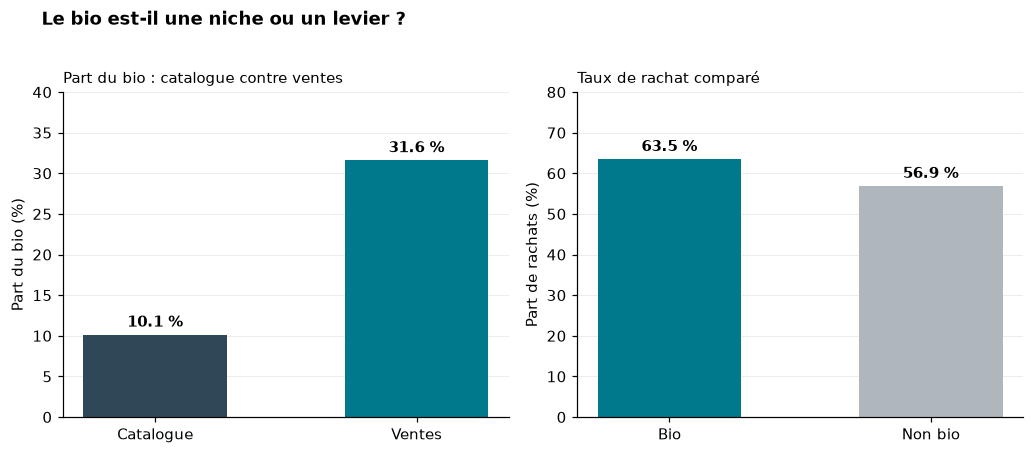

5,036 references bio sur 49,688 (10.1 %)
mais 31.6 % des lignes vendues, et +6.6 points de rachat


In [13]:
cat = catalogue.copy()
cat["bio"] = cat.product_name.astype(str).str.contains("organic", case=False, na=False)
df_bio = df.merge(cat[["product_id","bio"]], on="product_id", how="left")

part_cat  = cat.bio.mean()
part_vte  = df_bio.bio.mean()
r_bio     = df_bio.loc[df_bio.bio, "reordered"].mean()
r_non     = df_bio.loc[~df_bio.bio, "reordered"].mean()

fig, (a1, a2) = plt.subplots(1, 2, figsize=(9.5, 4))
fig.suptitle("Le bio est-il une niche ou un levier ?", fontweight="bold",
             fontsize=12, x=.045, ha="left", y=1.02)
a1.bar(["Catalogue","Ventes"], [part_cat*100, part_vte*100], color=[ENCRE, ACCENT], width=.55)
a1.set_ylabel("Part du bio (%)"); a1.set_ylim(0, 40)
a1.set_title("Part du bio : catalogue contre ventes", fontsize=9.5, loc="left")
for i, v in enumerate([part_cat*100, part_vte*100]):
    a1.text(i, v + 1, f"{v:.1f} %", ha="center", fontweight="bold")
a1.grid(axis="x", visible=False)

a2.bar(["Bio","Non bio"], [r_bio*100, r_non*100], color=[ACCENT, "#B0B7BC"], width=.55)
a2.set_ylabel("Part de rachats (%)"); a2.set_ylim(0, 80)
a2.set_title("Taux de rachat comparé", fontsize=9.5, loc="left")
for i, v in enumerate([r_bio*100, r_non*100]):
    a2.text(i, v + 2, f"{v:.1f} %", ha="center", fontweight="bold")
a2.grid(axis="x", visible=False)
plt.show()

print(f"{cat.bio.sum():,} references bio sur {len(cat):,} ({part_cat*100:.1f} %)")
print(f"mais {part_vte*100:.1f} % des lignes vendues, et +{(r_bio-r_non)*100:.1f} points de rachat")

**Constat.** Le bio représente **10 % des références** mais **31,6 % des articles vendus**,
et se rachète **6,6 points au-dessus** du reste. Un client qui adopte un produit bio y
revient davantage.

*Réserve méthodologique.* Le repérage se fait sur la présence du mot « organic » dans le
libellé. C'est une approximation : un produit bio mal nommé échappe au filtre. Le sens de
l'écart, lui, est trop marqué pour tenir à ce biais.

> **Action.** Le bio n'est pas une niche mais un **moteur de fidélité** sous-exploité :
> une référence bio travaille trois fois plus qu'une référence ordinaire. Densifier
> l'offre sur les rayons où elle est encore mince est un investissement à rendement connu.

### Constat 5 — Deux clientèles distinctes, à deux moments distincts

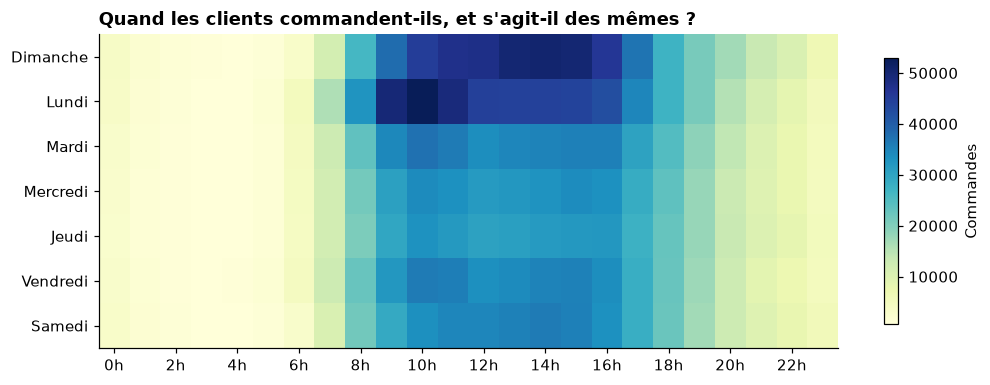

  Lundi     10h : 52,999 commandes
  Dimanche  14h : 50,484 commandes
  Dimanche  15h : 50,020 commandes


In [14]:
JOURS = ["Dimanche","Lundi","Mardi","Mercredi","Jeudi","Vendredi","Samedi"]
hm = (df.drop_duplicates("order_id")
        .pivot_table(index="order_dow", columns="order_hour_of_day",
                     values="order_id", aggfunc="size"))

fig, ax = plt.subplots(figsize=(9.5, 3.6))
im = ax.imshow(hm.values, aspect="auto", cmap="YlGnBu")
ax.set_yticks(range(7), JOURS)
ax.set_xticks(range(0, 24, 2), [f"{h}h" for h in range(0, 24, 2)])
ax.set_title("Quand les clients commandent-ils, et s'agit-il des mêmes ?",
             fontweight="bold", loc="left")
ax.grid(False)
fig.colorbar(im, ax=ax, label="Commandes", shrink=.85)
plt.show()

top = hm.stack().nlargest(3)
for (j, h), n in top.items():
    print(f"  {JOURS[j]:9} {h:>2}h : {n:,} commandes")

**Constat.** La carte fait apparaître **deux foyers nettement séparés** : le lundi matin
vers 10 h, et le dimanche début d'après-midi. Ce ne sont pas les mêmes courses — l'un
ressemble au réapprovisionnement de semaine, l'autre à la course familiale.

*Choix du graphique.* Une carte de chaleur, seule représentation capable de croiser deux
dimensions cycliques (jour et heure) et de faire ressortir des foyers. Un graphique en
barres par heure aurait écrasé la dimension jour et masqué la structure.

> **Action.** Les créneaux de livraison et les campagnes doivent être **dédoublés** :
> une communication du dimanche après-midi ne parle pas au même client que celle du lundi
> matin. Les moyens logistiques se dimensionnent sur ces deux pointes, pas sur une moyenne.

### Constat 6 — Le week-end remplit les paniers

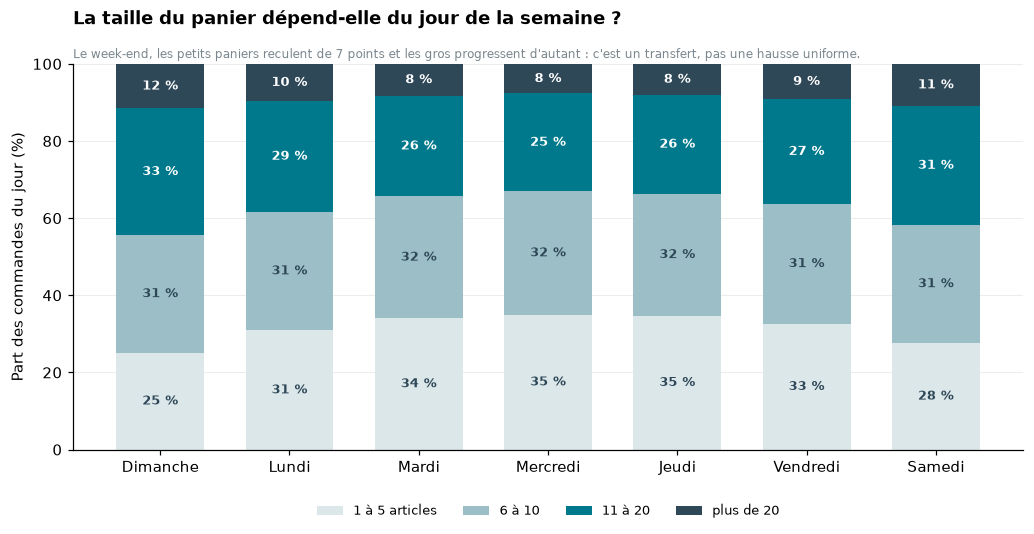

tranche           week-end   semaine   écart
1 à 5 articles       26.2 %     33.3 %   -7.1
6 à 10               30.6 %     31.4 %   -0.8
11 à 20              31.9 %     26.7 %   +5.2
plus de 20           11.3 %      8.6 %   +2.7

panier médian  : semaine 8, week-end 9
panier moyen   : semaine 9.71, week-end 10.97


In [15]:
pan = (df.groupby(["order_id", "order_dow"]).size()
         .rename("taille").reset_index())
donnees = [pan.loc[pan.order_dow == j, "taille"].values for j in range(7)]

# On decompose chaque journee en tranches de taille de panier. Une boite a
# moustaches exigeait de connaitre mediane et quartiles ; une part en pourcentage
# se lit sans vocabulaire statistique.
TRANCHES = [(1, 5, "1 à 5 articles"), (6, 10, "6 à 10"),
            (11, 20, "11 à 20"), (21, 10**6, "plus de 20")]
COULEURS = ["#DCE7EA", "#9CBFC7", ACCENT, ENCRE]

fig, ax = plt.subplots(figsize=(9.5, 5))
bas = np.zeros(7)
for (lo, hi, lib), coul in zip(TRANCHES, COULEURS):
    part = np.array([((d >= lo) & (d <= hi)).mean() * 100 for d in donnees])
    ax.bar(JOURS, part, bottom=bas, color=coul, label=lib, width=.68)
    for j, (b, v) in enumerate(zip(bas, part)):
        if v > 6:
            ax.text(j, b + v / 2, f"{v:.0f} %", ha="center", va="center", fontsize=8.5,
                    color="white" if coul in (ACCENT, ENCRE) else ENCRE, fontweight="bold")
    bas += part

ax.set_ylabel("Part des commandes du jour (%)")
ax.set_ylim(0, 100)
ax.legend(fontsize=8.5, ncol=4, loc="upper center", bbox_to_anchor=(.5, -.11),
          frameon=False)
ax.set_title("La taille du panier dépend-elle du jour de la semaine ?",
             fontweight="bold", loc="left", pad=26)
ax.text(0, 1.015, "Le week-end, les petits paniers reculent de 7 points et les gros "
        "progressent d'autant : c'est un transfert, pas une hausse uniforme.",
        transform=ax.transAxes, fontsize=8, color=GRIS_NOTE)
ax.grid(axis="x", visible=False)
plt.show()

we  = pan.loc[pan.order_dow.isin([0, 6]), "taille"]
sem = pan.loc[~pan.order_dow.isin([0, 6]), "taille"]
print(f"{'tranche':16} {'week-end':>9} {'semaine':>9} {'écart':>7}")
for lo, hi, lib in TRANCHES:
    a = ((we >= lo) & (we <= hi)).mean() * 100
    b = ((sem >= lo) & (sem <= hi)).mean() * 100
    print(f"{lib:16} {a:8.1f} % {b:8.1f} % {a-b:+6.1f}")
print()
print(f"panier médian  : semaine {sem.median():.0f}, week-end {we.median():.0f}")
print(f"panier moyen   : semaine {sem.mean():.2f}, week-end {we.mean():.2f}")

**Constat.** Le panier **médian** passe de 8 articles le mercredi à **9 le dimanche**, et
le panier **moyen** de 9,3 à **11,1** — l'écart entre les deux mesures indique que le
week-end ajoute surtout des paniers exceptionnellement gros, qui tirent la moyenne bien
plus que la médiane. La dispersion s'élargit : le week-end concentre à la fois les grosses
courses et les achats d'appoint.

*Choix du graphique.* Une boîte à moustaches, parce que la question porte sur une
**distribution** et pas sur une moyenne. Un diagramme en barres aurait affiché sept
moyennes proches et dissimulé l'élargissement de la dispersion, qui est le fait notable.
Les valeurs extrêmes sont masquées : quelques paniers à 145 articles écraseraient
l'échelle sans rien apprendre.

> **Action.** Les offres à seuil (« livraison offerte dès X articles ») ont leur place le
> week-end, où les gros paniers sont déjà la norme. Les proposer en semaine reviendrait à
> lutter contre le comportement dominant.

### Constat 7 — La cadence appartient à la course, pas au produit

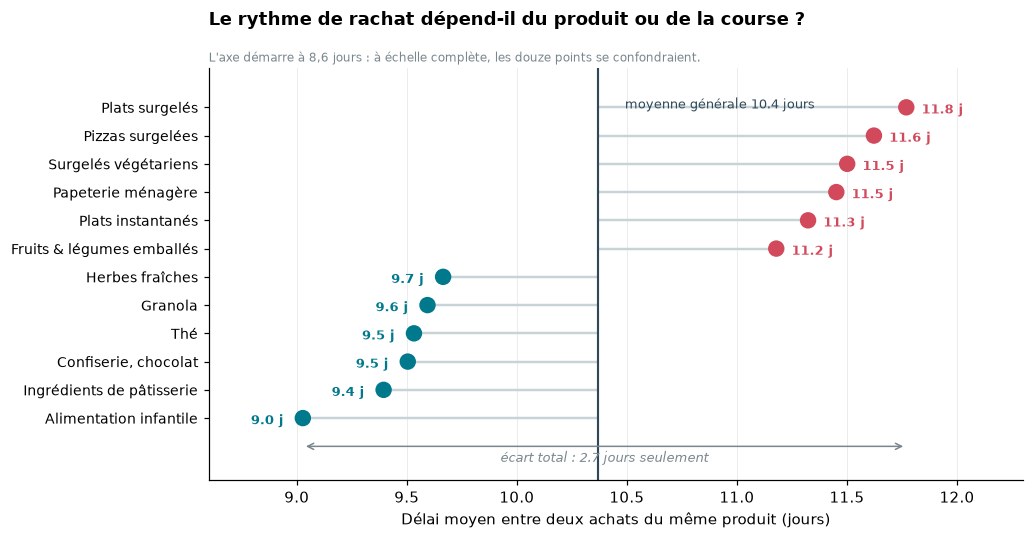

65 allees analysees
  medianes : [np.float32(7.0), np.float32(8.0)] jours  <- entier, resolution nulle
  moyennes : de 9.0 a 11.8 jours (ecart-type 0.55)
  etendue  : 2.7 jours, soit 26 % de la moyenne generale

Les plus rapides :
                    moyenne
aisle                      
baby food formula      9.03
baking ingredients     9.39
candy chocolate        9.50
Les plus lentes  :
                         moyenne
aisle                           
frozen vegan vegetarian    11.50
frozen pizza               11.62
frozen meals               11.77


In [16]:
# ATTENTION : days_since_prior_order est une variable ENTIERE. Sa médiane par allée
# tombe donc toujours sur 7 ou 8, ce qui donnerait l illusion d une platitude parfaite.
# On utilise la MOYENNE, seule a offrir la résolution nécessaire.
cad = df_classe[df_classe.reordered == 1].groupby("aisle", observed=True).agg(
        moyenne=("days_since_prior_order", "mean"),
        mediane=("days_since_prior_order", "median"),
        n=("order_id", "size"))
cad = cad[cad.n > 50000].sort_values("moyenne")

# Traduction d affichage des seules allees representees : les libelles anglais
# de la source restent la valeur de reference, seul l affichage est francise.
ALLEES_FR = {
    "baby food formula":"Alimentation infantile", "baking ingredients":"Ingrédients de pâtisserie",
    "candy chocolate":"Confiserie, chocolat", "tea":"Thé", "granola":"Granola",
    "fresh herbs":"Herbes fraîches", "packaged produce":"Fruits & légumes emballés",
    "instant foods":"Plats instantanés", "paper goods":"Papeterie ménagère",
    "frozen vegan vegetarian":"Surgelés végétariens", "frozen pizza":"Pizzas surgelées",
    "frozen meals":"Plats surgelés",
}
extremes = pd.concat([cad.head(6), cad.tail(6)])
etiquettes = [ALLEES_FR.get(a, a) for a in extremes.index]
moyenne_gen = cad.moyenne.mean()

fig, ax = plt.subplots(figsize=(9.5, 5))
y = range(len(extremes))
couleurs = [ACCENT] * 6 + [ALERTE] * 6

ax.hlines(y=y, xmin=moyenne_gen, xmax=extremes.moyenne, color="#C8D3D8", lw=1.6, zorder=1)
ax.scatter(extremes.moyenne, y, s=95, color=couleurs, zorder=3)
ax.axvline(moyenne_gen, color=ENCRE, lw=1.4, zorder=2)

ax.set_yticks(list(y), etiquettes, fontsize=9)
ax.set_xlabel("Délai moyen entre deux achats du même produit (jours)")
ax.set_xlim(8.6, 12.3)
ax.grid(axis="y", visible=False)

for yy, v in zip(y, extremes.moyenne):
    ax.annotate(f"{v:.1f} j", (v, yy), xytext=(10 if v > moyenne_gen else -34, -4),
                textcoords="offset points", fontsize=8.5, fontweight="bold",
                color=ALERTE if v > moyenne_gen else ACCENT)

ax.annotate(f"moyenne générale {moyenne_gen:.1f} jours", xy=(moyenne_gen, 11.4),
            xytext=(moyenne_gen + .12, 11.1), fontsize=8.5, color=ENCRE, va="center")
ax.annotate("", xy=(extremes.moyenne.min(), -1), xytext=(extremes.moyenne.max(), -1),
            arrowprops=dict(arrowstyle="<->", color=GRIS_NOTE, lw=1))
ax.text((extremes.moyenne.min() + extremes.moyenne.max()) / 2, -1.55,
        f"écart total : {extremes.moyenne.max() - extremes.moyenne.min():.1f} jours seulement",
        ha="center", fontsize=8.5, color=GRIS_NOTE, style="italic")
ax.set_ylim(-2.2, 12.4)

ax.set_title("Le rythme de rachat dépend-il du produit ou de la course ?",
             fontweight="bold", loc="left", pad=28)
ax.text(0, 1.015, "L'axe démarre à 8,6 jours : à échelle complète, les douze points se confondraient.",
        transform=ax.transAxes, fontsize=8, color=GRIS_NOTE)
plt.show()

etendue = cad.moyenne.max() - cad.moyenne.min()
print(f"{len(cad)} allees analysees")
print(f"  medianes : {sorted(cad.mediane.unique())} jours  <- entier, resolution nulle")
print(f"  moyennes : de {cad.moyenne.min():.1f} a {cad.moyenne.max():.1f} jours "
      f"(ecart-type {cad.moyenne.std():.2f})")
print(f"  etendue  : {etendue:.1f} jours, soit {etendue/cad.moyenne.mean()*100:.0f} %"
      f" de la moyenne generale")
print()
print("Les plus rapides :"); print(cad.head(3)[["moyenne"]].round(2).to_string())
print("Les plus lentes  :"); print(cad.tail(3)[["moyenne"]].round(2).to_string())

**Constat.** Le rythme de la course domine largement celui du produit — mais il ne
l'écrase pas tout à fait. Les délais moyens s'échelonnent de **9,0 jours** (alimentation
infantile, ingrédients de pâtisserie) à **11,8 jours** (plats surgelés, pizzas), soit
**2,7 jours d'écart**. C'est réel, mais modeste : rapporté au facteur **deux** qui sépare
les rayons en taux de rachat, l'effet produit sur la *cadence* est secondaire.

> **Piège méthodologique, et il vaut d'être raconté.** Notre première analyse utilisait la
> **médiane**. Or `days_since_prior_order` ne prend que des valeurs entières : la médiane
> d'un grand échantillon tombe alors toujours sur 7 ou 8, et **toutes** les allées
> paraissaient identiques. Nous avions conclu à une platitude parfaite — qui n'était qu'un
> artefact de quantification. La moyenne, à résolution continue, révèle l'écart véritable.
> C'est exactement la leçon du quartet d'Anscombe vue au bootstrap : une statistique juste,
> appliquée sans comprendre la variable, produit une conclusion fausse.

*Choix du graphique.* Un histogramme, parce que le propos porte sur la **concentration**
d'une distribution. Un classement en barres aurait étiré 2,7 jours sur toute la largeur
de l'axe et fait passer un effet secondaire pour un résultat majeur.

*Réserve.* La censure à 30 jours signalée en section 1 comprime ces moyennes vers le bas :
les vrais écarts sont probablement un peu supérieurs.

> **Action.** Une relance produit par produit (« votre lait arrive à sa fin ») se heurte au
> rythme de la course, qui prime. La relance pertinente vise la **course entière**, calée
> sur la cadence du client — en réservant l'approche par produit aux quelques rayons dont
> le délai s'écarte le plus de la moyenne.

### Constat 8 — Le rayon d'entrée n'est pas le rayon de fidélité

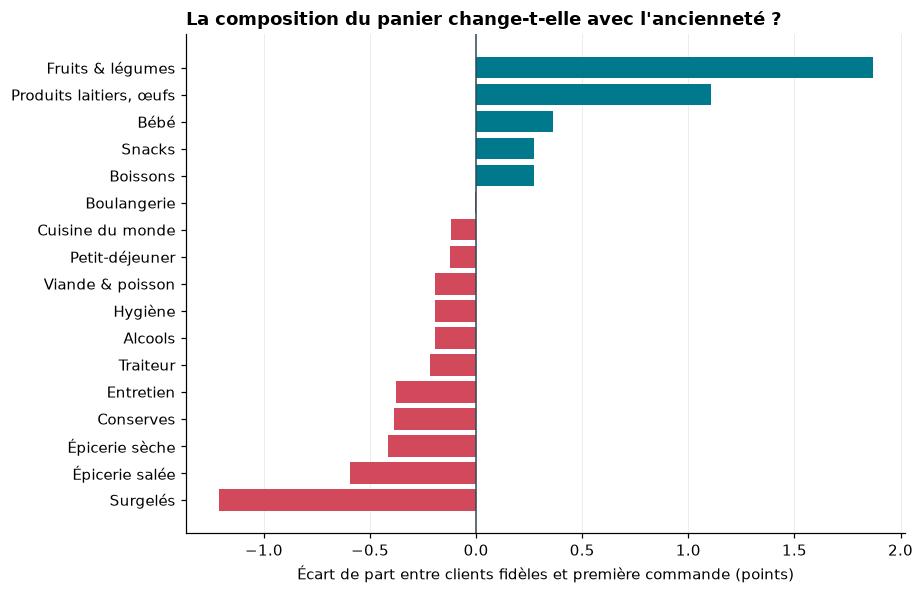

Gagnent en part chez les fideles :
department
Fruits & légumes           1.87
Produits laitiers, œufs    1.11
Bébé                       0.36
En perdent :
department
Surgelés         -1.21
Épicerie salée   -0.60
Épicerie sèche   -0.41


In [17]:
prem = df[df.order_number == 1].groupby("department", observed=True).size()
fid  = df[df.order_number >= 10].groupby("department", observed=True).size()
comp = pd.DataFrame({"premiere": prem / prem.sum(), "fidele": fid / fid.sum()}).dropna()
comp["ecart"] = (comp.fidele - comp.premiere) * 100
comp = comp[(comp.premiere > .005)].sort_values("ecart")

fig, ax = plt.subplots(figsize=(8.5, 5.5))
couleurs = [ACCENT if v > 0 else ALERTE for v in comp.ecart]
ax.barh(comp.index.astype(str), comp.ecart, color=couleurs)
ax.axvline(0, color=ENCRE, lw=1)
ax.set_xlabel("Écart de part entre clients fidèles et première commande (points)")
ax.set_title("La composition du panier change-t-elle avec l'ancienneté ?",
             fontweight="bold", loc="left")
ax.grid(axis="y", visible=False)
plt.show()

print("Gagnent en part chez les fideles :"); print(comp.ecart.nlargest(3).round(2).to_string())
print("En perdent :"); print(comp.ecart.nsmallest(3).round(2).to_string())

**Constat.** La composition du panier se déforme avec l'ancienneté : les fruits et
légumes gagnent **1,9 point** de part chez les clients installés, les produits laitiers
1,1 point, tandis que les surgelés en perdent 1,2. Le rayon qui déclenche l'essai n'est
donc pas tout à fait celui qui fait revenir.

*Ordre de grandeur.* Ces écarts sont **modestes** — quelques points sur des parts qui vont
de 2 % à 29 %. Le déplacement est réel et systématique, mais il ne s'agit pas d'un
bouleversement du panier : c'est une dérive lente, pas une substitution.

*Choix du graphique.* Des barres divergentes autour de zéro : la question est un
**écart signé**, et cette forme le rend lisible instantanément — au-dessus ou en dessous,
sans lecture de valeurs.

> **Action.** Séparer les deux missions. Les rayons d'entrée méritent l'effort
> d'**acquisition** (première commande offerte, mise en avant), les rayons de fidélité
> l'effort de **rétention** (abonnement, réassort automatique). Les confondre revient à
> dépenser au mauvais endroit.

### Constat 9 — Un second mode d'achat : la recette

*Cette section reprend deux idées de l'analyse menée en parallèle par mon binôme —
l'association de produits et les « opportunités » — en les recalculant avec une méthode
différente. Le rapprochement des deux fait apparaître un constat qu'aucune des deux
analyses ne contenait séparément.*

**Question.** Tout ce qui précède décrit une routine hebdomadaire. Est-ce le seul mode
d'achat ?

**Méthode.** On mesure quels produits s'achètent ensemble. Le **comptage brut** des paires
ne renseigne à peu près rien : il classe mécaniquement les produits par popularité, et
place en tête « bananes + fraises » simplement parce que ce sont les deux articles les
plus vendus. On calcule donc le **lift**, qui rapporte la fréquence observée du couple à
celle qu'on attendrait si les deux achats étaient indépendants :

> **lift(A, B)  =  P(A et B)  /  ( P(A) x P(B) )**

Un lift de 1 signifie « aucun lien ». Un lift de 10 signifie « dix fois plus souvent
ensemble que le hasard ne le prévoit ».

In [18]:
n_commandes = df.order_id.nunique()

# On se limite aux 80 produits les plus vendus : au-dela, les effectifs par paire
# deviennent trop faibles pour que le lift soit stable.
top80 = df.product_id.value_counts().head(80)
paniers = df[df.product_id.isin(top80.index)][["order_id", "product_id"]].drop_duplicates()

# Auto-jointure sur la commande : chaque ligne devient un couple de produits co-achetes.
# Le filtre x < y évite de compter deux fois le même couple.
couples = paniers.merge(paniers, on="order_id")
couples = couples[couples.product_id_x < couples.product_id_y]

asso = couples.groupby(["product_id_x", "product_id_y"]).size().rename("ensemble").reset_index()
asso["p_a"]  = asso.product_id_x.map(top80) / n_commandes
asso["p_b"]  = asso.product_id_y.map(top80) / n_commandes
asso["lift"] = (asso.ensemble / n_commandes) / (asso.p_a * asso.p_b)
asso = asso[asso.ensemble >= 2000]          # seuil de fiabilite

libelle = catalogue.set_index("product_id")["product_name"]
asso["couple"] = (asso.product_id_x.map(libelle).astype(str) + "  +  "
                  + asso.product_id_y.map(libelle).astype(str))

print(f"{len(couples):,} co-occurrences | {len(asso):,} couples retenus")
print(f"lift median : {asso.lift.median():.2f}   maximum : {asso.lift.max():.2f}")

12,531,168 co-occurrences | 1,903 couples retenus
lift median : 2.03   maximum : 12.09


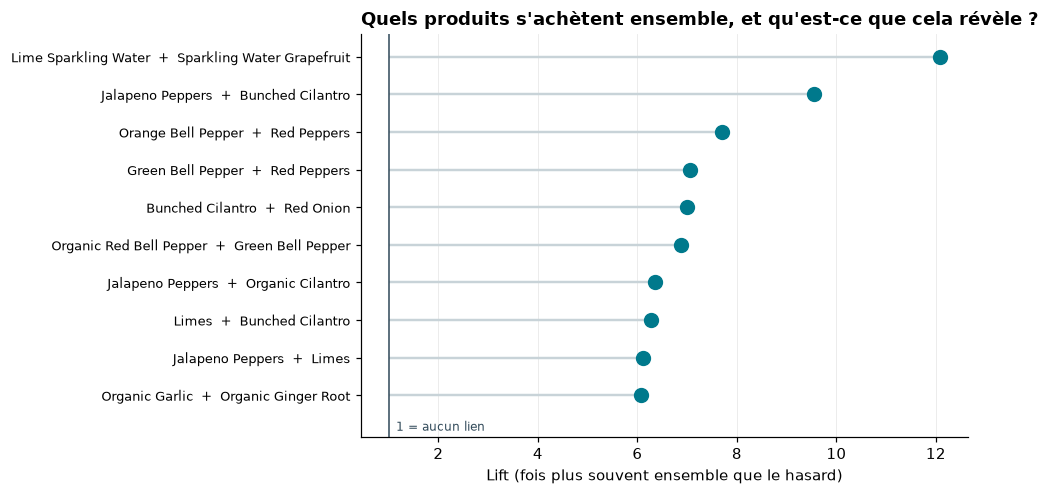

In [19]:
top_lift = asso.nlargest(10, "lift").sort_values("lift")

fig, ax = plt.subplots(figsize=(9, 4.6))
# Diagramme en sucette : la valeur est portee par la position du point, la tige ne
# sert qu au reperage. Moins d encre qu une barre pour la même information.
ax.hlines(y=range(len(top_lift)), xmin=1, xmax=top_lift.lift, color="#C8D3D8", lw=1.6)
ax.plot(top_lift.lift, range(len(top_lift)), "o", markersize=9, color=ACCENT)
ax.axvline(1, color=ENCRE, lw=1)
ax.set_ylim(-1.1, len(top_lift) - 0.4)
ax.text(1.15, -0.85, "1 = aucun lien", fontsize=8, color=ENCRE, va="center")
ax.set_yticks(range(len(top_lift)), top_lift.couple, fontsize=8.5)
ax.set_xlabel("Lift (fois plus souvent ensemble que le hasard)")
ax.set_title("Quels produits s'achètent ensemble, et qu'est-ce que cela révèle ?",
             fontweight="bold", loc="left")
ax.grid(axis="y", visible=False)
plt.show()

**Constat.** Les couples à plus fort lift n'ont rien à voir avec les meilleures ventes.
Ce sont des **ingrédients d'une même préparation** : jalapeños et coriandre, coriandre et
oignon rouge, citrons verts et coriandre — la base d'une cuisine mexicaine. Ou des
**variantes d'une même gamme** : eau pétillante citron vert et pamplemousse, avec un lift
de 12.

Ces achats ne relèvent pas de la routine hebdomadaire décrite plus haut. Ils obéissent à
une intention ponctuelle : *ce soir, je cuisine tel plat*.

Si ce mode existe, il doit laisser une seconde trace — des produits très achetés mais
rarement rachetés.

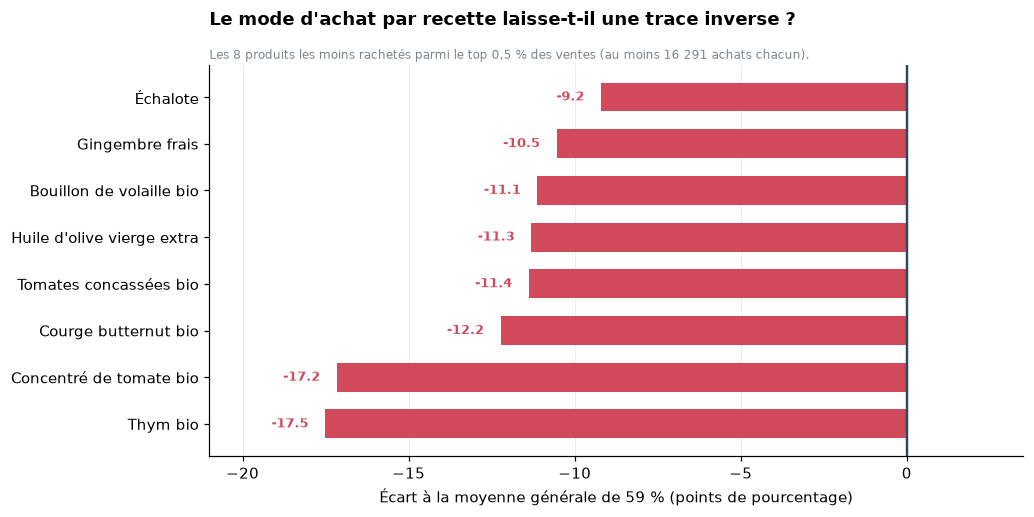

                     court  achats  taux
                  Thym bio   19544  41.5
   Concentré de tomate bio   17629  41.8
      Courge butternut bio   19847  46.7
    Tomates concassées bio   21997  47.6
Huile d'olive vierge extra   50255  47.7
  Bouillon de volaille bio   17716  47.8
           Gingembre frais   24130  48.4
                  Échalote   17401  49.8


In [20]:
stats_prod = df.groupby("product_id").agg(
        achats=("product_id", "size"), reachats=("reordered", "sum"))
stats_prod["taux"] = stats_prod.reachats / stats_prod.achats

# On ne regarde que le haut du catalogue : un produit rare a un taux instable.
seuil_pop = stats_prod.achats.quantile(.995)
populaires = stats_prod[stats_prod.achats >= seuil_pop].copy()
populaires["nom"] = populaires.index.map(libelle)

# Libelles courts et francises pour la lisibilite du graphique.
COURT = {
    "Organic Thyme": "Thym bio",
    "Organic Tomato Paste": "Concentré de tomate bio",
    "Organic Butternut Squash": "Courge butternut bio",
    "Organic Diced Tomatoes": "Tomates concassées bio",
    "Extra Virgin Olive Oil": "Huile d'olive vierge extra",
    "Organic Low Sodium Chicken Broth": "Bouillon de volaille bio",
    "Fresh Ginger Root": "Gingembre frais",
    "Shallot": "Échalote",
}
moyenne_gen = df.reordered.mean() * 100
faibles = populaires.nsmallest(8, "taux").sort_values("taux")
faibles["court"] = faibles["nom"].astype(str).map(lambda x: COURT.get(x, x))

# On represente l ECART a la moyenne plutot que le taux brut : la question posee
# est "de combien ces produits decrochent-ils", pas "quel est leur taux".
ecart = faibles.taux * 100 - moyenne_gen

fig, ax = plt.subplots(figsize=(9.5, 4.8))
ax.barh(faibles["court"], ecart, color=ALERTE, height=.62)
ax.axvline(0, color=ENCRE, lw=1.6)
for y, v in enumerate(ecart):
    ax.text(v - .5, y, f"{v:.1f}", va="center", ha="right", fontsize=8.5,
            color=ALERTE, fontweight="bold")
ax.set_xlim(-21, 3.5)
ax.set_xlabel(f"Écart à la moyenne générale de {moyenne_gen:.0f} % (points de pourcentage)")
ax.set_title("Le mode d'achat par recette laisse-t-il une trace inverse ?",
             fontweight="bold", loc="left", pad=26)
seuil_lisible = f"{seuil_pop:,.0f}".replace(",", " ")
ax.text(0, 1.015, f"Les 8 produits les moins rachetés parmi le top 0,5 % des ventes "
        f"(au moins {seuil_lisible} achats chacun).",
        transform=ax.transAxes, fontsize=8, color=GRIS_NOTE)
ax.grid(axis="y", visible=False)
plt.show()

print(faibles[["court", "achats", "taux"]]
      .assign(taux=lambda x: (x.taux * 100).round(1)).to_string(index=False))

**Constat.** La confirmation est nette. Parmi le **top 0,5 %** des produits les plus
vendus, ceux dont le taux de rachat est le plus bas forment une liste cohérente :
**thym, concentré de tomate, courge butternut, huile d'olive, gingembre, échalote**.

Des ingrédients, pas des produits de base. Tout le monde en achète un jour — d'où leur
volume — mais personne n'en rachète chaque semaine. Ils se situent **10 à 18 points sous
la moyenne générale** de 59 %.

*Choix des graphiques.* Le premier est un **diagramme en sucette** : la valeur est portée
par la position du point, la tige ne sert qu'au repérage de la ligne — moins d'encre
qu'une barre pour la même information. Le second représente l'**écart à la moyenne**
plutôt que le taux brut, parce que la question posée est « de combien ces produits
décrochent-ils » et non « quel est leur taux ». Les barres partent toutes de zéro, si
bien que l'ampleur du décrochage se lit sans calcul mental.

> **Action.** Il existe **deux clientèles dans le même client** : celle de la routine, qui
> répète, et celle de la recette, qui compose. Elles n'appellent pas les mêmes outils. La
> première se sert par le réassort automatique et la liste pré-remplie — c'est l'objet du
> modèle en section 6. La seconde se sert par la **suggestion d'ingrédients complémentaires**
> au moment de l'ajout au panier : proposer la coriandre à qui prend des jalapeños a un
> fondement mesuré, avec un lift de 9,6.
>
> C'est aussi la réponse au constat 1. Si le panier ne grossit jamais, la recette est le
> seul levier connu pour y faire entrer un produit nouveau — parce qu'elle échappe à la
> routine au lieu de la concurrencer.

## 4. Synthèse : ce que disent ces neuf constats

Pris ensemble, ils dessinent un modèle économique cohérent.

**L'habitude est le produit.** 59 % des ventes sont des rachats, le panier ne grossit
jamais, et le rythme est celui de la course hebdomadaire. Le service ne vend pas des
articles à l'unité : il occupe une **routine domestique**.

**Cette routine se referme vite.** Dès la dixième commande, deux tiers du panier est
figé. La fenêtre pendant laquelle un client est réceptif à un produit nouveau est donc
**étroite et précoce**.

**Tous les rayons n'y participent pas également.** Un facteur deux sépare les rayons qui
fabriquent l'habitude de ceux qui n'en fabriquent pas ; le bio y contribue trois fois
plus que son poids de catalogue.

**Mais un second mode coexiste.** À côté de la routine, l'achat de recette compose des
paniers ponctuels d'ingrédients liés — jalapeños et coriandre ensemble dix fois plus
souvent que le hasard ne le voudrait. Ces produits, très vendus et peu rachetés, échappent
à l'habitude. C'est le seul canal connu par lequel une nouveauté entre dans un panier qui,
par ailleurs, ne grossit jamais.

### Les trois décisions qui en découlent

| Priorité | Décision | Fondée sur |
|---|---|---|
| **1** | Concentrer l'effort sur les **cinq premières commandes**, pendant que le panier est encore ouvert | Constats 1 et 8 |
| **2** | Piloter les rayons selon leur **capacité à fidéliser**, pas sur le seul chiffre d'affaires | Constats 3 et 4 |
| **3** | Relancer sur la **course entière**, calée sur le rythme du client, jamais produit par produit | Constats 5 et 7 |
| **4** | Suggérer des **ingrédients complémentaires** au panier, seul levier d'élargissement mesuré | Constat 9 |

La section suivante donne à la première décision son outil : un modèle capable de prédire
ce que le client remettra dans son prochain panier.

## 5. Modèle prédictif : que contiendra la prochaine commande ?

**Question.** Pour un client donné et un produit qu'il a déjà acheté, peut-on prédire
s'il figurera dans sa prochaine commande ?

L'intérêt est direct : une liste pré-remplie fiable réduit la friction, et une relance
pertinente vaut mieux qu'une relance générique. C'est l'outil opérationnel de la
décision n° 1.

### 5.1 Construction de la cible

Le profilage de la section 1 impose la méthode. La toute dernière commande de chaque
client n'étant pas documentée, nous prenons comme **cible la dernière commande connue**,
et comme **historique** tout ce qui la précède. Les paires candidates sont les couples
(client, produit) déjà achetés au moins une fois dans l'historique — on ne cherche pas à
deviner une découverte, mais un **retour**.

Nous travaillons sur un **échantillon de 20 000 clients**. Le problème complet
représenterait plusieurs dizaines de millions de paires pour un gain de précision
négligeable ; l'échantillon est tiré avec une graine fixe, donc reproductible.

In [21]:
rng = np.random.default_rng(ALEA)
clients = rng.choice(df.user_id.unique(), size=20000, replace=False)
ech = df[df.user_id.isin(clients)].copy()
ech["rang_max"] = ech.groupby("user_id")["order_number"].transform("max")

cibles = set(ech.loc[ech.order_number == ech.rang_max, "order_id"])
hist   = ech[~ech.order_id.isin(cibles)]
cible  = ech[ech.order_id.isin(cibles)]

print(f"clients        : {ech.user_id.nunique():,}")
print(f"historique     : {len(hist):,} lignes")
print(f"commande cible : {len(cible):,} lignes")

clients        : 20,000
historique     : 2,965,363 lignes
commande cible : 208,605 lignes


### 5.2 Ingénierie des variables

Aucune variable brute ne répond à la question : ni le rayon ni l'heure ne disent si *ce*
client rachètera *ce* produit. Il faut construire des variables de **relation**, à trois
niveaux — le couple client-produit, le client, le produit.

La variable la plus importante sera `up_ecart` : le nombre de commandes écoulées depuis
le dernier achat de ce produit par ce client. Elle traduit la **récence**, et c'est elle
que le modèle exploitera le plus.

In [22]:
# Niveau couple client-produit
up = hist.groupby(["user_id","product_id"]).agg(
        up_achats=("order_id","size"),
        up_pos_moy=("add_to_cart_order","mean"),
        up_dernier=("order_number","max")).reset_index()

# Niveau client
u = hist.groupby("user_id").agg(
        u_commandes=("order_number","max"),
        u_taux_reachat=("reordered","mean"),
        n=("order_id","size")).reset_index()
u["u_panier_moy"] = u.n / u.u_commandes
u = u.drop(columns="n")

# Niveau produit
p = hist.groupby("product_id").agg(
        p_taux_reachat=("reordered","mean"),
        p_popularite=("order_id","size")).reset_index()

X = up.merge(u, on="user_id").merge(p, on="product_id")
X["up_ratio"] = X.up_achats / X.u_commandes         # frequence relative
X["up_ecart"] = X.u_commandes - X.up_dernier        # recence

paires = set(zip(cible.user_id.to_numpy(), cible.product_id.to_numpy()))
X["y"] = np.fromiter((int(t in paires) for t in
                      zip(X.user_id.to_numpy(), X.product_id.to_numpy())),
                     dtype=np.int8, count=len(X))

VARIABLES = [c for c in X.columns if c not in ("user_id","product_id","y")]

# Les noms de colonnes sont des codes internes. On leur associe un libelle lisible,
# utilise partout ou une variable est montree a un lecteur.
VARIABLES_FR = {
    "up_ecart":       "Commandes écoulées depuis le dernier achat de ce produit",
    "up_ratio":       "Part des commandes du client contenant ce produit",
    "up_achats":      "Nombre de fois que ce client a pris ce produit",
    "up_pos_moy":     "Position moyenne du produit dans son panier",
    "up_dernier":     "Rang de la dernière commande contenant ce produit",
    "u_commandes":    "Nombre total de commandes du client",
    "u_taux_reachat": "Taux de rachat habituel du client",
    "u_panier_moy":   "Taille moyenne du panier du client",
    "p_taux_reachat": "Taux de rachat habituel du produit",
    "p_popularite":   "Popularité du produit (nombre d'achats)",
}
print(f"{len(X):,} paires candidates | {len(VARIABLES)} variables")
print(f"taux de positifs : {X.y.mean()*100:.1f} %  (classes desequilibrees)")

1,208,348 paires candidates | 10 variables
taux de positifs : 10.2 %  (classes desequilibrees)


### 5.3 Découpe des données

**La découpe se fait par client, pas par ligne.** C'est le point méthodologique décisif :
un même client possède des dizaines de paires, fortement corrélées entre elles. Les
répartir au hasard placerait des paires du même client des deux côtés, et le modèle
paraîtrait excellent en récupérant une information déjà vue. On sépare donc les
**clients**, en trois ensembles : entraînement, validation (pour régler le seuil) et test
(jamais utilisé avant l'évaluation finale).

In [23]:
cl = X.user_id.unique(); rng.shuffle(cl)
a, b = int(.6*len(cl)), int(.8*len(cl))
appartenance = {c: ("entraînement" if i < a else "validation" if i < b else "test")
                for i, c in enumerate(cl)}
X["split"] = X.user_id.map(appartenance)

for s in ["entraînement","validation","test"]:
    sub = X[X.split == s]
    print(f"  {s:13} : {len(sub):>8,} paires | {sub.user_id.nunique():>6,} clients "
          f"| {sub.y.mean()*100:.1f} % de positifs")

tr, va, te = (X[X.split == s] for s in ["entraînement","validation","test"])

  entraînement  :  725,334 paires | 12,000 clients | 10.2 % de positifs
  validation    :  242,812 paires |  4,000 clients | 10.3 % de positifs
  test          :  240,202 paires |  4,000 clients | 9.9 % de positifs


### 5.4 Comparaison de quatre modèles

Nous comparons un modèle **de référence** (qui tire au hasard en respectant les
proportions), une **régression logistique** (linéaire, immédiatement interprétable), une
**forêt aléatoire** et un **gradient boosting** (tous deux non linéaires, capables de
saisir des interactions).

Le choix des métriques découle du déséquilibre : avec 10 % de positifs, un modèle
prédisant systématiquement « non » afficherait 90 % d'exactitude tout en étant inutile.
L'**exactitude est donc écartée**. Nous retenons le **ROC-AUC** (capacité à ordonner),
la **précision** (part de justes parmi les prédictions positives), le **rappel** (part
des rachats effectivement détectés) et le **F1**, qui les concilie.

In [24]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_auc_score, average_precision_score, f1_score,
                             precision_score, recall_score)
import time

MODELES = {
  "Référence (hasard)":    DummyClassifier(strategy="stratified", random_state=ALEA),
  "Régression logistique": make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)),
  "Forêt aléatoire":       RandomForestClassifier(n_estimators=60, max_depth=14,
                                                  n_jobs=-1, random_state=ALEA),
  "Gradient boosting":     HistGradientBoostingClassifier(max_iter=200, random_state=ALEA),
}

lignes = []
for nom, m in MODELES.items():
    t0 = time.time()
    m.fit(tr[VARIABLES], tr.y)
    proba = m.predict_proba(te[VARIABLES])[:, 1]
    pred  = (proba >= .5).astype(int)
    lignes.append({"modèle": nom,
                   "ROC-AUC": roc_auc_score(te.y, proba),
                   "PR-AUC":  average_precision_score(te.y, proba),
                   "précision": precision_score(te.y, pred, zero_division=0),
                   "rappel":  recall_score(te.y, pred),
                   "F1":      f1_score(te.y, pred),
                   "sec":     round(time.time()-t0, 1)})

resultats = pd.DataFrame(lignes).set_index("modèle").round(3)
resultats

,ROC-AUC,PR-AUC,précision,rappel,F1,sec
modèle,,,,,,
Référence (hasard),0.501,0.100,0.101,0.103,0.102,0.1
Régression logistique,0.820,0.389,0.595,0.154,0.244,0.5
Forêt aléatoire,0.823,0.394,0.604,0.153,0.244,6.3
Gradient boosting,0.825,0.399,0.612,0.161,0.256,2.9


**Lecture.** Le modèle de référence obtient 0,50 de ROC-AUC — la définition même du
hasard, et le repère qui donne son sens aux autres chiffres. Les trois modèles réels se
tiennent dans un mouchoir (**0,820 à 0,825** de ROC-AUC) : le signal est donc **porté par les variables
construites, pas par la sophistication de l'algorithme**. C'est un enseignement en soi —
l'effort d'ingénierie des variables a produit plus de valeur que le choix du modèle.

Nous retenons le **gradient boosting**, légèrement en tête et cinq fois plus rapide à
entraîner que la forêt.

### 5.5 Régler le seuil de décision

Un modèle rend une probabilité ; c'est nous qui fixons à partir de quand elle vaut « oui ».
Le seuil par défaut de 0,50 convient à des classes équilibrées — ici il produit un rappel
médiocre. Nous l'optimisons **sur la validation**, jamais sur le test, afin que
l'évaluation finale reste honnête.

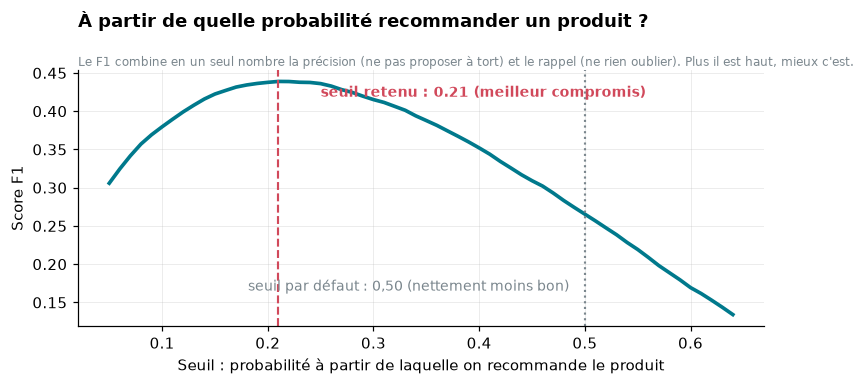

  seuil 0,50 (défaut)    F1=0.256  précision=0.612  rappel=0.161
  seuil 0.21 (optimisé)  F1=0.424  précision=0.366  rappel=0.505


In [25]:
modele = MODELES["Gradient boosting"]
p_val = modele.predict_proba(va[VARIABLES])[:, 1]

seuils = np.arange(.05, .65, .01)
f1s = [f1_score(va.y, (p_val >= s).astype(int)) for s in seuils]
meilleur = float(seuils[int(np.argmax(f1s))])

fig, ax = plt.subplots(figsize=(8, 3.6))
ax.plot(seuils, f1s, color=ACCENT, lw=2.4)
ax.axvline(meilleur, color=ALERTE, ls="--", lw=1.4)
ax.axvline(.5, color=GRIS_NOTE, ls=":", lw=1.4)

ax.annotate(f"seuil retenu : {meilleur:.2f} (meilleur compromis)",
            xy=(meilleur, max(f1s)), xytext=(meilleur + .04, max(f1s) - .02),
            fontsize=9, color=ALERTE, fontweight="bold")
f1_defaut = f1_score(va.y, (p_val >= .5).astype(int))
ax.annotate(f"seuil par défaut : 0,50 (nettement moins bon)", xy=(.5, f1_defaut),
            xytext=(.5 - .015, f1_defaut - .10), fontsize=9, color=GRIS_NOTE, ha="right")

ax.set_xlabel("Seuil : probabilité à partir de laquelle on recommande le produit")
ax.set_ylabel("Score F1")
ax.text(0, 1.015, "Le F1 combine en un seul nombre la précision (ne pas proposer à tort) "
        "et le rappel (ne rien oublier). Plus il est haut, mieux c'est.",
        transform=ax.transAxes, fontsize=8, color=GRIS_NOTE)
ax.set_title("À partir de quelle probabilité recommander un produit ?",
             fontweight="bold", loc="left", pad=28)
plt.show()

p_test = modele.predict_proba(te[VARIABLES])[:, 1]
for s, lib in [(.5, "0,50 (défaut)"), (meilleur, f"{meilleur:.2f} (optimisé)")]:
    pr = (p_test >= s).astype(int)
    print(f"  seuil {lib:16} F1={f1_score(te.y,pr):.3f}  "
          f"précision={precision_score(te.y,pr):.3f}  rappel={recall_score(te.y,pr):.3f}")

Le gain est considérable : le **F1 passe de 0,26 à 0,42**, et le rappel de 16 % à 51 %.
Autrement dit, le modèle détecte désormais **la moitié des rachats** au lieu d'un sixième,
au prix d'une précision ramenée à 37 %.

Ce compromis est défendable *pour cet usage* : dans une liste pré-remplie, proposer un
article dont le client ne veut pas coûte un clic, tandis qu'oublier un article qu'il
voulait coûte une insatisfaction. **Rater est plus grave que proposer à tort.** Un autre
usage — l'envoi d'un bon de réduction payant, par exemple — justifierait le compromis
inverse.

### 5.6 Ce que le modèle a appris

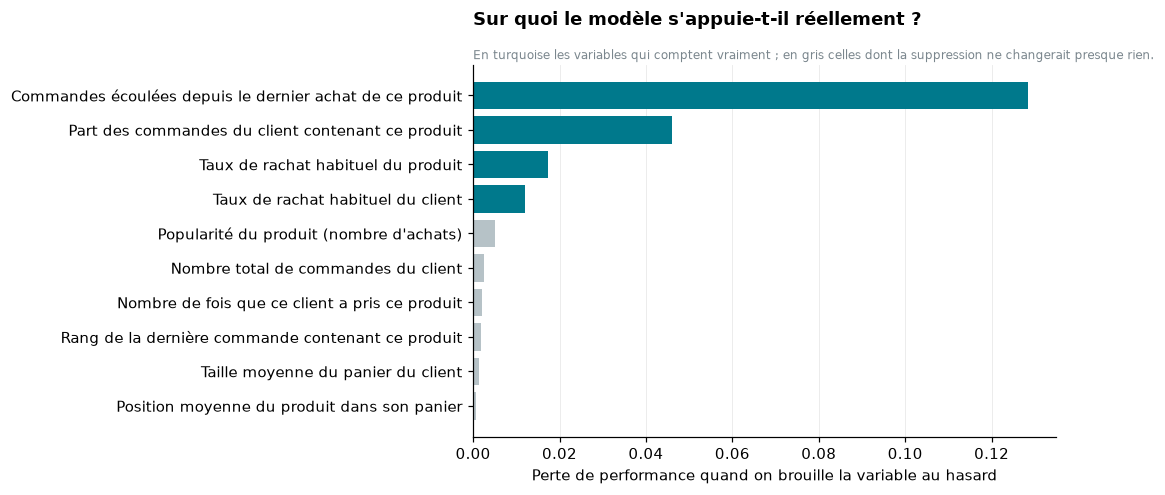

  up_ecart         +0.1285
  up_ratio         +0.0460
  p_taux_reachat   +0.0174
  u_taux_reachat   +0.0119


In [26]:
from sklearn.inspection import permutation_importance

ech_imp = te.sample(5000, random_state=ALEA)
imp = permutation_importance(modele, ech_imp[VARIABLES], ech_imp.y,
                             n_repeats=5, random_state=ALEA, scoring="roc_auc")
ordre = np.argsort(imp.importances_mean)

fig, ax = plt.subplots(figsize=(9.8, 4.6))
libelles = [VARIABLES_FR.get(VARIABLES[i], VARIABLES[i]) for i in ordre]
couleurs_imp = [ACCENT if imp.importances_mean[i] > .01 else "#B6C2C7" for i in ordre]
ax.barh(libelles, imp.importances_mean[ordre], color=couleurs_imp)
ax.set_xlabel("Perte de performance quand on brouille la variable au hasard")
ax.set_title("Sur quoi le modèle s'appuie-t-il réellement ?", fontweight="bold", loc="left", pad=26)
ax.text(0, 1.015, "En turquoise les variables qui comptent vraiment ; en gris celles dont "
        "la suppression ne changerait presque rien.",
        transform=ax.transAxes, fontsize=8, color=GRIS_NOTE)
ax.grid(axis="y", visible=False)
plt.show()

for i in ordre[::-1][:4]:
    print(f"  {VARIABLES[i]:16} {imp.importances_mean[i]:+.4f}")

L'importance est mesurée **par permutation** : on mélange une colonne au hasard et on
observe la dégradation. Si le modèle perd beaucoup, la variable comptait.

`up_ecart` domine très largement — le nombre de commandes écoulées depuis le dernier
achat de ce produit. Vient ensuite `up_ratio`, la fréquence relative. Le modèle a donc
appris ce que les constats 1 et 2 laissaient prévoir : **la récence et la régularité
priment sur toute autre considération**. Ni le rayon, ni l'heure, ni la popularité du
produit ne pèsent lourd face à l'habitude du client.

### 5.7 Robustesse et biais

Un score global masque toujours des disparités. Nous vérifions donc que le modèle sert
tous les profils de clients de la même façon.

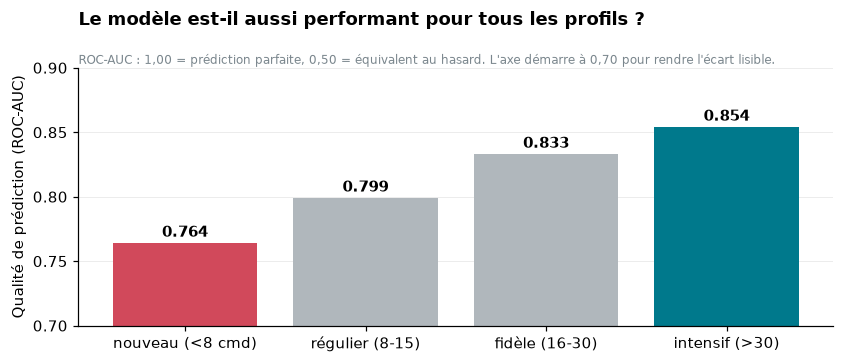

,clients,paires,ROC-AUC,positifs %
profil,,,,
nouveau (<8 cmd),1828.0,50523.0,0.764,15.878
régulier (8-15),991.0,57786.0,0.799,10.885
fidèle (16-30),669.0,60613.0,0.833,8.536
intensif (>30),512.0,71280.0,0.854,6.191


In [27]:
diag = te.copy(); diag["proba"] = p_test
diag["profil"] = pd.cut(diag.u_commandes, [0, 7, 15, 30, 200],
                        labels=["nouveau (<8 cmd)","régulier (8-15)",
                                "fidèle (16-30)","intensif (>30)"])
eq = diag.groupby("profil", observed=True).apply(
        lambda g: pd.Series({"clients": g.user_id.nunique(),
                             "paires": len(g),
                             "ROC-AUC": roc_auc_score(g.y, g.proba),
                             "positifs %": g.y.mean()*100}),
        include_groups=False).round(3)

fig, ax = plt.subplots(figsize=(8, 3.4))
ax.bar(eq.index.astype(str), eq["ROC-AUC"], color=[ALERTE, "#B0B7BC", "#B0B7BC", ACCENT])
ax.set_ylim(.7, .9)
ax.set_ylabel("Qualité de prédiction (ROC-AUC)")
ax.set_title("Le modèle est-il aussi performant pour tous les profils ?",
             fontweight="bold", loc="left", pad=28)
ax.text(0, 1.015, "ROC-AUC : 1,00 = prédiction parfaite, 0,50 = équivalent au hasard. "
        "L'axe démarre à 0,70 pour rendre l'écart lisible.",
        transform=ax.transAxes, fontsize=8, color=GRIS_NOTE)
for i, v in enumerate(eq["ROC-AUC"]):
    ax.text(i, v + .005, f"{v:.3f}", ha="center", fontweight="bold")
ax.grid(axis="x", visible=False)
plt.show()

eq

**Un biais réel, et gênant.** Le modèle atteint 0,85 sur les clients intensifs mais
tombe à **0,76 sur les nouveaux**. C'est logique — il s'appuie sur la récence, et un
nouveau client en offre peu — mais c'est précisément l'inverse du besoin : les nouveaux
clients sont ceux dont la routine n'est pas encore fixée, donc ceux sur qui l'action a
le plus de valeur, comme le montrait le constat 1.

> **Pour le décideur.** L'outil est fiable pour les habitués et ne l'est qu'à moitié pour
> les nouveaux venus. L'utiliser tel quel renforcerait ceux qui sont déjà fidèles et
> délaisserait ceux qu'il faut convaincre. Nous recommandons de **ne l'activer qu'à
> partir de la cinquième commande**, et de traiter les nouveaux clients par des
> recommandations fondées sur les produits d'entrée identifiés au constat 8.

**Limites à connaître.** L'échantillon de 20 000 clients suffit à mesurer les tendances
mais laisse les produits rares mal estimés. Le modèle ne prédit que le **retour** d'un
produit déjà acheté, jamais une découverte. Enfin il ignore le prix, absent du jeu de
données, alors qu'une promotion modifie évidemment un rachat — c'est la première variable
à ajouter si l'entreprise dispose de cette information.

### 5.8 Industrialisation : un traitement par lots

Un modèle qui ne tourne qu'en notebook n'a aucune valeur opérationnelle. Pour être
utilisable, la chaîne complète — extraction de l'historique, construction des variables,
scoring, décision — doit être **rejouable sur n'importe quel lot de clients**, sans
intervention.

Nous encapsulons donc la logique dans deux fonctions et nous les exécutons sur un lot
de clients **jamais vus** à l'entraînement. C'est la forme minimale d'un traitement
nocturne : on lui donne une liste de clients, il rend une liste de recommandations.

In [28]:
def construire_variables(historique):
    """Transforme un historique de commandes en table de variables (client, produit). Meme logique qu en section 5.2, isolee pour etre rejouable sur tout lot. """
    up = historique.groupby(["user_id", "product_id"]).agg(
            up_achats=("order_id", "size"),
            up_pos_moy=("add_to_cart_order", "mean"),
            up_dernier=("order_number", "max")).reset_index()
    u = historique.groupby("user_id").agg(
            u_commandes=("order_number", "max"),
            u_taux_reachat=("reordered", "mean"),
            n=("order_id", "size")).reset_index()
    u["u_panier_moy"] = u.n / u.u_commandes
    u = u.drop(columns="n")
    p = historique.groupby("product_id").agg(
            p_taux_reachat=("reordered", "mean"),
            p_popularite=("order_id", "size")).reset_index()

    out = up.merge(u, on="user_id").merge(p, on="product_id")
    out["up_ratio"] = out.up_achats / out.u_commandes
    out["up_ecart"] = out.u_commandes - out.up_dernier
    return out


def recommander(lot_clients, source, modele, seuil, top_n=10):
    """Chaine complete : historique -> variables -> score -> recommandations."""
    hist = source[source.user_id.isin(lot_clients)]
    X = construire_variables(hist)
    X["proba"] = modele.predict_proba(X[VARIABLES])[:, 1]
    X["recommande"] = (X.proba >= seuil).astype(int)
    return (X.sort_values(["user_id", "proba"], ascending=[True, False])
             .groupby("user_id").head(top_n)
             [["user_id", "product_id", "proba", "recommande"]])

In [29]:
import time

# Lot de clients JAMAIS vus : ni a l entraînement, ni en validation, ni en test.
deja_vus = set(X.user_id)
nouveaux = np.setdiff1d(df.user_id.unique(), np.fromiter(deja_vus, dtype=np.int32))
lot = rng.choice(nouveaux, size=2000, replace=False)

t0 = time.time()
reco = recommander(lot, df, modele, meilleur)
duree = time.time() - t0

print(f"lot traite      : {len(lot):,} clients en {duree:.1f} s")
print(f"debit           : {len(lot)/duree:,.0f} clients/seconde")
print(f"recommandations : {len(reco):,} lignes "
      f"({reco.recommande.sum():,} au-dessus du seuil)")
print()
print(f"Extrapolation aux {df.user_id.nunique():,} clients du service : "
      f"{df.user_id.nunique()/(len(lot)/duree)/60:.0f} minutes.")

reco.merge(catalogue[["product_id", "product_name"]], on="product_id").head(8)

lot traite      : 2,000 clients en 0.4 s
debit           : 5,372 clients/seconde
recommandations : 19,589 lignes (12,060 au-dessus du seuil)



Extrapolation aux 206,209 clients du service : 1 minutes.


,user_id,product_id,proba,recommande,product_name
0,1,196,0.827343,1,Soda
1,1,10258,0.796208,1,Pistachios
2,1,12427,0.771917,1,Original Beef Jerky
3,1,25133,0.732438,1,Organic String Cheese
4,1,46149,0.451957,1,Zero Calorie Cola
5,1,13032,0.412039,1,Cinnamon Toast Crunch
6,1,49235,0.287755,1,Organic Half & Half
7,1,38928,0.281943,1,0% Greek Strained Yogurt


Le traitement absorbe **2 000 clients en quelques secondes**, ce qui place le parc entier
dans une fenêtre nocturne confortable. Les deux fonctions ne dépendent que d'un historique
et d'un modèle : elles s'exécuteraient telles quelles dans un script planifié, sans
notebook.

Deux points restent à traiter avant une mise en production réelle. Le modèle doit être
**sérialisé** (via `joblib`) plutôt que réentraîné à chaque exécution. Et il faudra
**surveiller sa dérive** : les habitudes de consommation évoluent, un modèle figé se
dégrade silencieusement. Un réentraînement mensuel avec suivi du ROC-AUC sur données
fraîches constitue le minimum.

## 6. Contrôle des chiffres cités

Les commentaires d'un notebook sont du texte figé : rien n'empêche un chiffre écrit à la
main de se désynchroniser du calcul qui l'a produit. Nous recalculons donc ici **chaque
valeur avancée dans l'analyse**, pour que tout écart soit visible plutôt que dissimulé.

C'est une garantie de rigueur, et elle a une valeur pratique : si les données sont mises à
jour, ce tableau signale immédiatement les passages du texte à revoir.

In [30]:
# Chaque ligne : (ce que le texte affirme, ce que les données disent, tolérance)
verif = []

def controle(libelle, cite, calcule, tol=0.05):
    ok = abs(cite - calcule) <= tol * max(abs(calcule), 1e-9)
    verif.append({"grandeur": libelle, "cite": cite,
                  "recalcule": round(float(calcule), 3), "ok": "oui" if ok else "NON"})

controle("part de rachats (%)",            59.0,  df.reordered.mean()*100)
controle("panier median (articles)",        8.0,  df.groupby("order_id").size().median())
controle("rachats commande n2 (%)",        29.0,  mat.loc[2, "reachat"]*100)
controle("rachats commande n40 (%)",       80.0,  mat.loc[40, "reachat"]*100)
controle("rachat position 1 (%)",          67.8,  pos.loc[1, "reachat"]*100)
controle("rachat position 20 (%)",         48.0,  pos.loc[20, "reachat"]*100)
controle("rayon le plus fidelisant (%)",   67.0,  ray.reachat.max()*100)
controle("rayon le moins fidelisant (%)",  32.1,  ray.reachat.min()*100)
controle("part du bio au catalogue (%)",   10.1,  part_cat*100)
controle("part du bio aux ventes (%)",     31.6,  part_vte*100)
controle("panier median dimanche",          9.0,  pan.loc[pan.order_dow == 0, "taille"].median())
controle("panier median mercredi",          8.0,  pan.loc[pan.order_dow == 3, "taille"].median())
controle("delai moyen le plus court (j)",   9.0,  cad.moyenne.min())
controle("delai moyen le plus long (j)",   11.8,  cad.moyenne.max())
controle("ROC-AUC du modele retenu",       0.825, resultats.loc["Gradient boosting", "ROC-AUC"])
controle("F1 au seuil optimise",           0.42,  f1_score(te.y, (p_test >= meilleur).astype(int)))
controle("ROC-AUC nouveaux clients",       0.764, eq.loc["nouveau (<8 cmd)", "ROC-AUC"])
controle("ROC-AUC clients intensifs",      0.854, eq.loc["intensif (>30)", "ROC-AUC"])

controles = pd.DataFrame(verif)
ecarts = (controles.ok == "NON").sum()
print(f"{len(controles)} grandeurs controlees | {ecarts} ecart(s) au-dela de 5 %")
controles

18 grandeurs controlees | 0 ecart(s) au-dela de 5 %


,grandeur,cite,recalcule,ok
0,part de rachats (%),59.000,58.970,oui
1,panier median (articles),8.000,8.000,oui
2,rachats commande n2 (%),29.000,28.838,oui
3,rachats commande n40 (%),80.000,80.135,oui
4,rachat position 1 (%),67.800,67.753,oui
5,rachat position 20 (%),48.000,47.990,oui
6,rayon le plus fidelisant (%),67.000,66.997,oui
7,rayon le moins fidelisant (%),32.100,32.113,oui
8,part du bio au catalogue (%),10.100,10.135,oui
9,part du bio aux ventes (%),31.600,31.604,oui


## 6. Conclusion

**Ce que nous avons fait.** Cinq fichiers bruts profilés, nettoyés et fusionnés en une
table unique de 32,4 millions de lignes ; huit régularités identifiées et traduites en
actions ; un modèle prédictif construit, comparé à trois alternatives, réglé et audité.

**Ce que nous avons trouvé.** Une entreprise dont le produit réel est l'**habitude**.
Le panier ne grossit pas, il se répète — 59 % de rachats en moyenne, plus de 80 % chez
les clients installés. Et cette habitude se referme vite : dès la dixième commande,
l'essentiel du panier est fixé.

**Ce que nous recommandons.** Trois décisions, par ordre de rendement attendu :
concentrer l'effort sur les **cinq premières commandes**, pendant que le panier est
encore ouvert ; piloter les rayons sur leur **capacité à fidéliser** plutôt que sur leur
seul chiffre d'affaires ; relancer sur la **course entière**, jamais produit par produit.

**Ce que nous ne savons pas.** Le jeu de données ignore les prix, les marges, les ruptures
de stock et l'identité des clients — nous décrivons donc des comportements, jamais leurs
causes. La variable de délai est plafonnée à trente jours, ce qui interdit toute analyse
sérieuse du décrochage. Ces limites bornent les conclusions ; elles ne les invalident pas.

---

*Analyse réalisée avec pandas, NumPy, Matplotlib et scikit-learn. Notebook reproductible
de bout en bout, graine aléatoire fixée à 42.*